In [16]:
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

# Set default figure size
plt.rcParams["figure.figsize"] = (10, 6)

CMAP_10 = [
    "#3f90da",
    "#ffa90e",
    "#bd1f01",
    "#94a4a2",
    "#832db6",
    "#a96b59",
    "#e76300",
    "#b9ac70",
    "#717581",
    "#92dadd",
]

COLOR_ALIASES = {
    "CMS_blue": CMAP_10[0],        # Blue
    "CMS_orange": CMAP_10[1],      # Orange
    "CMS_red": CMAP_10[2],         # Red
    "CMS_gray": CMAP_10[3],        # Gray
    "CMS_purple": CMAP_10[4],      # Purple
    "CMS_brown": CMAP_10[5],       # Brown
    "CMS_dark_orange": CMAP_10[6], # Dark Orange
    "CMS_beige": CMAP_10[7],       # Beige
    "CMS_dark_gray": CMAP_10[8],   # Dark Gray
    "CMS_light_blue": CMAP_10[9]   # Light Blue
}
CMS_blue = COLOR_ALIASES["CMS_blue"]
CMS_red = COLOR_ALIASES["CMS_red"]

In [2]:
filename = "/home/mmarcheg/work/ml4reco/hgcal_reco_studies/data/hgcal_v1_20260818-T193435/epoch=199-val_loss=11.54392__test.parquet"
df = ak.from_parquet(filename)
df.fields

['RecHitHGC',
 'MergedSimCluster',
 'TICLCand',
 'Candidate2Tracksters',
 'ticlTrackstersCLUE3DHigh',
 'ticlTracksterLinks',
 'ticlTrackstersRecovery',
 'LayerCluster',
 'SimCluster',
 'n_fake_particles',
 'event_number']

In [8]:
df.LayerCluster.fields

['LayerCluster_x',
 'LayerCluster_y',
 'LayerCluster_z',
 'LayerCluster_eta',
 'LayerCluster_phi',
 'LayerCluster_energy',
 'LayerCluster_nHits',
 'LayerCluster_seedDetId',
 'LayerCluster_SimCluster_MatchIdx',
 'LayerCluster_SimCluster_MatchQual',
 'LayerCluster_SimClusterNumMatch',
 'LayerCluster_CaloPart_MatchIdx',
 'LayerCluster_CaloPart_MatchQual',
 'LayerCluster_CaloPartNumMatch',
 'LayerCluster_pred_match_idx']

In [28]:
idx_pred = df.LayerCluster.LayerCluster_pred_match_idx
idx_true = df.LayerCluster.LayerCluster_SimCluster_MatchIdx

ak.sum(ak.flatten(index) == -2) / len(ak.flatten(index))

0.3856435101821546

In [32]:
ak.flatten(idx_true)

<Array [0, 0, 0, 0, 0, ... 25, 25, 25, 25, 8] type='236269 * int64'>

In [ ]:
ak.flatten(idx_pred)

<Array [-2, -2, -2, -2, -2, ... 25, 25, 25, 25] type='201038 * int64'>

In [12]:
df.SimCluster.fields

['SimCluster_bunchCrossing',
 'SimCluster_eventId',
 'SimCluster_pdgId',
 'SimCluster_trackIdAtBoundary',
 'SimCluster_boundaryEnergy',
 'SimCluster_impactPoint_eta',
 'SimCluster_impactPoint_phi',
 'SimCluster_impactPoint_x',
 'SimCluster_impactPoint_y',
 'SimCluster_impactPoint_z',
 'SimCluster_recEnergy',
 'SimCluster_CaloPartIdx',
 'SimCluster_isPileup',
 'SimCluster_pred_class',
 'SimCluster_pred_valid',
 'SimCluster_pred_n_nodes',
 'SimCluster_pred_e',
 'SimCluster_pred_eta',
 'SimCluster_pred_sinphi',
 'SimCluster_pred_cosphi',
 'SimCluster_pred_r',
 'SimCluster_pred_phi']

In [13]:
e = df.SimCluster.SimCluster_boundaryEnergy
e_pred = df.SimCluster.SimCluster_pred_e
e_pred

<Array [[1.56], [22.6, ... 50.3, 1.98, 0.282]] type='1000 * var * float32'>

In [15]:
resolution = ak.flatten((e_pred - e) / e)
resolution

<Array [-0.602, -0.506, ... -0.028, -0.69] type='9055 * float32'>

Text(1, 0, 'Resolution (E_pred - E_true) / E_true')

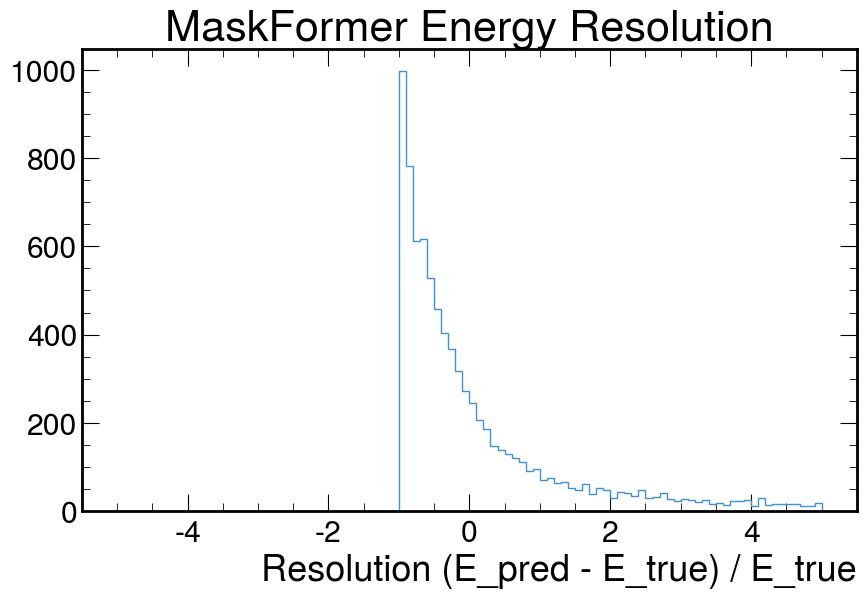

In [21]:
plt.hist(resolution, bins=100, range=(-5, 5), histtype="step", color=CMS_blue, label="MaskFormer");
plt.title("MaskFormer Energy Resolution")
plt.xlabel("Resolution (E_pred - E_true) / E_true")